# Vježbe 13 — GAN i cGAN: Generativne mreže
**Predmet:** Rudarenje podataka — I. godina — II ciklus — Softversko inženjerstvo  
**Asistent:** ass. mr. Narcisa Hadžajlić  
**Datum:** 18.5.2026.

---

## Šta smo do sada naučili
- **Vježbe 8–9:** MLP, aktivacijske funkcije, regularizacija
- **Vježbe 10:** CNN — konvolucija, filteri, feature mape
- **Vježbe 11:** Transfer Learning — VGG16, ResNet50
- **Vježbe 12:** Vremenske serije — Trend, Sezonalnost, LSTM

## Potpuno novi pristup: Generativni modeli

Sve što smo radili do sada je bila **diskriminativna** paradigma:
- Dajemo modelu podatke → model uči **klasificirati** ili **predvidjeti**
- Pitanje: *"Kojoj klasi pripada ovaj uzorak?"*

**GAN (Generative Adversarial Network)** je fundamentalno drugačiji:
- Model uči **generisati** nove podatke koji izgledaju kao pravi
- Pitanje: *"Kako izgledaju podaci iz ove distribucije?"*
- Primjene: generisanje slika, augmentacija podataka, deepfake detekcija, sintetički podaci za trening

### Plan:
1. GAN intuicija — krivotvoritelj vs. detektiv
2. Arhitektura: Generator + Discriminator (zbog toga se zove "adversarial")
3. Vanilla GAN na MNIST-u
4. cGAN — uslovljeno generisanje (kontrolišemo šta generišemo)
5. Vizualizacija: kako se slike poboljšavaju kroz epohe
6. Zadatak

---
## 1. GAN Intuicija: Krivotvoritelj vs. Detektiv

GAN ima dva modela koja se takmiče:

**Generator (G)** — krivotvoritelj. Prima nasumični šum (latentni vektor `z`) i pokušava napraviti lažne slike koje izgledaju stvarno. Na početku pravi besmislicu. Želi prevariti discriminatora.

**Discriminator (D)** — detektiv. Prima sliku i treba reći: stvarna ili lažna? Na početku lako prepoznaje lažne. Želi razotkriti generatora.

```
Šum (z) → [Generator] → Lažna slika ┐
                                      ├→ [Discriminator] → Stvarna/Lažna?
Pravi dataset        → Prava slika  ┘
```

**Trening je igra:**
- Discriminator uči razlikovati prave od lažnih → postaje bolji detektiv
- Generator uči varati discriminatora → postaje bolji krivotvoritelj
- Ravnoteža (Nash equilibrium): Generator pravi slike koje su 50/50 i discriminator više ne može razlikovati

### GAN vs. cGAN

**Vanilla GAN:** Generator prima samo šum → generira nasumičnu sliku (ne kontrolišemo šta će biti)

**cGAN (Conditional GAN):** Generator prima šum + labelu klase → generira sliku **određene** klase
- Šum + `labela=3` → generira trojku
- Šum + `labela=7` → generira sedmicu

> **Ključna razlika od CNN-a:** CNN layeri u Generatoru nemaju nodove koji gledaju cijelu sliku odjednom — koriste **transponiranu konvoluciju** koja uvećava feature mapu. Rastemo od malog vektora šuma do pune slike.

---
## 2. Implementacija

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

tf.get_logger().setLevel('ERROR')
np.random.seed(42)
tf.random.set_seed(42)

# Dimenzije latentnog prostora — veličina ulaznog šuma za Generator
LATENT_DIM  = 100
IMG_SHAPE   = (28, 28, 1)
N_KLASA     = 10

print(f"TensorFlow: {tf.__version__}")
print(f"Latentni prostor: {LATENT_DIM}D")
print("Sve uvezeno!")

TensorFlow: 2.21.0
Latentni prostor: 100D
Sve uvezeno!


### 2.1 Dataset i preprocessing

Train shape: (60000, 28, 28, 1)
Vrijednosti: min=-1.0, max=1.0
Normalizacija [-1, 1] — obavezno za GAN s tanh outputom!


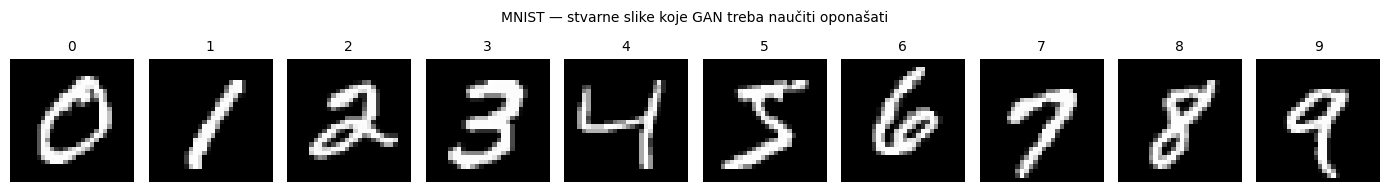

In [2]:
(X_train, y_train), (_, _) = mnist.load_data()

# GAN preprocessing — normalizacija u [-1, 1] umjesto [0, 1]
# Zašto [-1, 1]? Generator koristi tanh aktivaciju na outputu
# tanh vraća vrijednosti u [-1, 1] pa moraju biti isti opseg kao prave slike
X_train = (X_train.astype('float32') - 127.5) / 127.5
X_train = X_train[..., np.newaxis]  # dodaj channel dim: (60000, 28, 28, 1)

print(f"Train shape: {X_train.shape}")
print(f"Vrijednosti: min={X_train.min():.1f}, max={X_train.max():.1f}")
print("Normalizacija [-1, 1] — obavezno za GAN s tanh outputom!")

# Vizualizacija
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(X_train[idx, :, :, 0], cmap='gray')
    axes[i].set_title(str(i), fontsize=10)
    axes[i].axis('off')
plt.suptitle('MNIST — stvarne slike koje GAN treba naučiti oponašati', fontsize=10)
plt.tight_layout()
plt.show()

---
## 3. Dio A — Vanilla GAN

Počinjemo s jednostavnim MLP GAN-om (bez konvolucije) da razumijemo mehaniku.

### 3.1 Generator

Generator prima vektor šuma (`latent_dim` dimenzija) i transformira ga u sliku.
Arhitektura raste: mali vektor → veći vektori → slika.

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,520 (5.70 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 3,584 (14.00 KB)

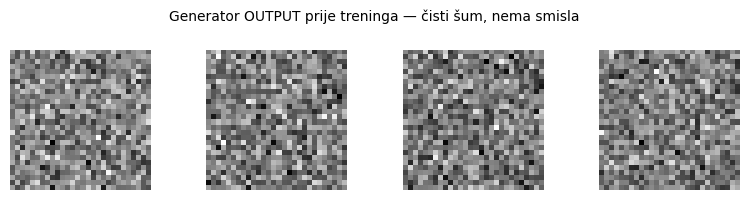

In [3]:
def napravi_generator(latent_dim):
    model = keras.Sequential([
        layers.Input(shape=(latent_dim,)),

        # Rastemo od latent_dim → 256 → 512 → 784
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        # LeakyReLU u Generatoru: spriječava "dying neurons"
        # Za negativne vrijednosti: output = 0.2 * input (ne 0 kao ReLU)

        layers.Dense(512),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Dense(1024),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        # Output: 784 = 28×28, aktivacija tanh → [-1, 1]
        layers.Dense(28 * 28 * 1, activation='tanh'),
        layers.Reshape((28, 28, 1))  # pretvori u sliku
    ], name='Generator')
    return model


generator = napravi_generator(LATENT_DIM)
generator.summary()

# Provjera: što generator radi s nasumičnim šumom PRIJE treninga?
test_sum = tf.random.normal([4, LATENT_DIM])
test_slike = generator(test_sum, training=False)

fig, axes = plt.subplots(1, 4, figsize=(8, 2))
for i, ax in enumerate(axes):
    ax.imshow(test_slike[i, :, :, 0], cmap='gray')
    ax.axis('off')
plt.suptitle('Generator OUTPUT prije treninga — čisti šum, nema smisla', fontsize=10)
plt.tight_layout()
plt.show()

### 3.2 Discriminator

Discriminator prima sliku i vraća vjerovatnoću da je **stvarna** (1) ili **lažna** (0).

In [4]:
def napravi_discriminator():
    model = keras.Sequential([
        layers.Input(shape=IMG_SHAPE),
        layers.Flatten(),

        # Smanjujemo: 784 → 512 → 256 → 1
        layers.Dense(512),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        # Dropout u Discriminatoru sprečava da postane "predobar"
        # Ako je D predobar, G ne može naučiti ništa korisno

        layers.Dense(256),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        # Output: jedna vjerovatnoća — stvarna ili lažna?
        layers.Dense(1, activation='sigmoid')
    ], name='Discriminator')
    return model


discriminator = napravi_discriminator()
discriminator.summary()

discriminator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    # beta_1=0.5 umjesto 0.9 — standardna GAN praksa, stabilniji trening
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

### 3.3 GAN model — spajamo Generator i Discriminator

Za trening Generatora: zamrzavamo Discriminator, prolazimo šum kroz G → D, i mjerimo koliko dobro G vara D.

In [5]:
# GAN = Generator + zamrznuti Discriminator
# Koristimo za trening Generatora
z_input  = keras.Input(shape=(LATENT_DIM,))
fake_img = generator(z_input)

# Discriminator je zamrznut dok treniramo Generator
discriminator.trainable = False
validity = discriminator(fake_img)

gan = keras.Model(z_input, validity, name='GAN')
gan.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss='binary_crossentropy'
)

print("GAN model:")
print(f"  Input:  šum oblika ({LATENT_DIM},)")
print(f"  Output: vjerovatnoća (1 = Discriminator misli da je slika STVARNA)")
print(f"\nTrening logika:")
print(f"  1. Treniraj Discriminator: prave slike → labela 1, lažne slike → labela 0")
print(f"  2. Treniraj Generator: lažne slike → labela 1 (varamo D da misli da su stvarne)")
print(f"  3. Ponovi za svaki batch")

GAN model:
  Input:  šum oblika (100,)
  Output: vjerovatnoća (1 = Discriminator misli da je slika STVARNA)

Trening logika:
  1. Treniraj Discriminator: prave slike → labela 1, lažne slike → labela 0
  2. Treniraj Generator: lažne slike → labela 1 (varamo D da misli da su stvarne)
  3. Ponovi za svaki batch


### 3.4 Trening petlja — srce GAN-a

GAN trening nije standardan `model.fit()` — piše se ručno jer imamo dvije izmjenične faze.

In [6]:
def prikazi_slike(generator, latent_dim, epoha, n=25):
    """Generiše i prikazuje n slika na kraju svake epohe."""
    sum_ = np.random.normal(0, 1, (n, latent_dim))
    generirane = generator.predict(sum_, verbose=0)
    # Inverz normalizacije: [-1,1] → [0,1] za prikaz
    generirane = (generirane + 1) / 2.0

    fig, axes = plt.subplots(5, 5, figsize=(7, 7))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generirane[i, :, :, 0], cmap='gray')
        ax.axis('off')
    plt.suptitle(f'Generirane slike — Epoha {epoha}', fontsize=12)
    plt.tight_layout()
    plt.show()


def treniraj_gan(generator, discriminator, gan,
                 X_train, latent_dim,
                 n_epoha=30, batch_size=128,
                 prikaz_svakih=10):

    n_batch     = X_train.shape[0] // batch_size
    historija_d = []  # discriminator loss
    historija_g = []  # generator loss

    # Labele: 1 = stvarno, 0 = lažno
    # Label smoothing: 0.9 umjesto 1.0 za stvarne → stabilniji trening
    prave_labele = np.ones((batch_size, 1)) * 0.9
    lazne_labele = np.zeros((batch_size, 1))

    print(f"Trening: {n_epoha} epoha, {n_batch} batcheva po epohi")
    print("-" * 55)

    for epoha in range(1, n_epoha + 1):
        d_lossi, g_lossi = [], []

        for _ in range(n_batch):

            # ── Korak 1: Treniraj Discriminator ──────────────────
            # a) Na stvarnim slikama
            idx         = np.random.randint(0, X_train.shape[0], batch_size)
            prave_slike = X_train[idx]
            d_loss_prav = discriminator.train_on_batch(prave_slike, prave_labele)

            # b) Na lažnim slikama
            sum_         = np.random.normal(0, 1, (batch_size, latent_dim))
            lazne_slike  = generator.predict(sum_, verbose=0)
            d_loss_laz   = discriminator.train_on_batch(lazne_slike, lazne_labele)

            d_loss = 0.5 * (d_loss_prav[0] + d_loss_laz[0])
            d_lossi.append(d_loss)

            # ── Korak 2: Treniraj Generator ───────────────────────
            # Generator pokušava prevariti D: šaljemo LAŽNE slike s labelom 1
            sum_    = np.random.normal(0, 1, (batch_size, latent_dim))
            g_loss  = gan.train_on_batch(sum_, prave_labele)  # ← labela 1!
            g_lossi.append(g_loss)

        # Prosjek losseva za epohu
        d_avg = np.mean(d_lossi)
        g_avg = np.mean(g_lossi)
        historija_d.append(d_avg)
        historija_g.append(g_avg)

        print(f"Epoha {epoha:3d}/{n_epoha}  |  D loss: {d_avg:.4f}  |  G loss: {g_avg:.4f}")

        if epoha % prikaz_svakih == 0 or epoha == 1:
            prikazi_slike(generator, latent_dim, epoha)

    return historija_d, historija_g


print("Sve pripremljeno. Pokretanje treninga...")
print("(Trening može potrajati 5-15 minuta ovisno o CPU-u)")

Sve pripremljeno. Pokretanje treninga...
(Trening može potrajati 5-15 minuta ovisno o CPU-u)


Trening: 30 epoha, 468 batcheva po epohi
-------------------------------------------------------
Epoha   1/30  |  D loss: 1.1189  |  G loss: 0.3440


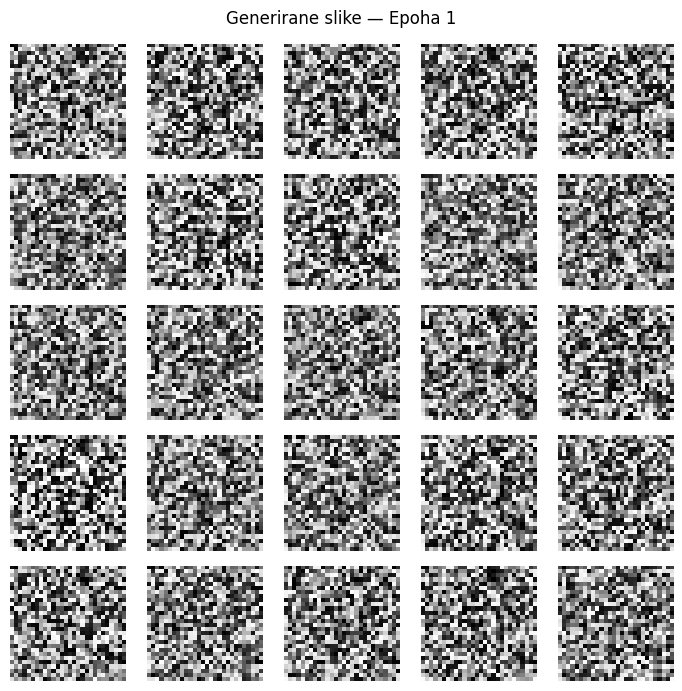

Epoha   2/30  |  D loss: 1.3588  |  G loss: 0.3321
Epoha   3/30  |  D loss: 1.4231  |  G loss: 0.3305
Epoha   4/30  |  D loss: 1.4508  |  G loss: 0.3297
Epoha   5/30  |  D loss: 1.4664  |  G loss: 0.3293
Epoha   6/30  |  D loss: 1.4764  |  G loss: 0.3289
Epoha   7/30  |  D loss: 1.4835  |  G loss: 0.3287
Epoha   8/30  |  D loss: 1.4885  |  G loss: 0.3285
Epoha   9/30  |  D loss: 1.4922  |  G loss: 0.3284
Epoha  10/30  |  D loss: 1.4953  |  G loss: 0.3282


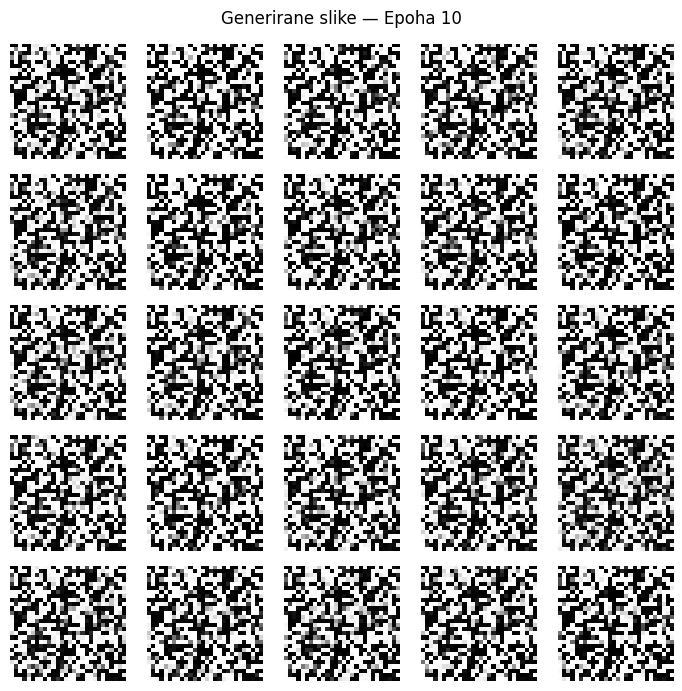

Epoha  11/30  |  D loss: 1.4977  |  G loss: 0.3281
Epoha  12/30  |  D loss: 1.4996  |  G loss: 0.3280
Epoha  13/30  |  D loss: 1.5012  |  G loss: 0.3280
Epoha  14/30  |  D loss: 1.5026  |  G loss: 0.3279
Epoha  15/30  |  D loss: 1.5038  |  G loss: 0.3278
Epoha  16/30  |  D loss: 1.5048  |  G loss: 0.3278
Epoha  17/30  |  D loss: 1.5058  |  G loss: 0.3277
Epoha  18/30  |  D loss: 1.5066  |  G loss: 0.3277
Epoha  19/30  |  D loss: 1.5074  |  G loss: 0.3277
Epoha  20/30  |  D loss: 1.5080  |  G loss: 0.3276


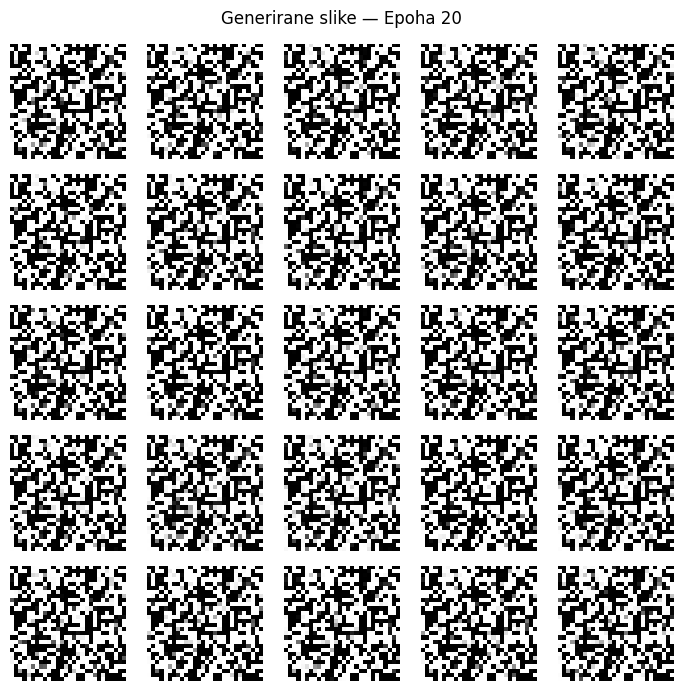

Epoha  21/30  |  D loss: 1.5086  |  G loss: 0.3276
Epoha  22/30  |  D loss: 1.5092  |  G loss: 0.3276
Epoha  23/30  |  D loss: 1.5097  |  G loss: 0.3276
Epoha  24/30  |  D loss: 1.5102  |  G loss: 0.3275
Epoha  25/30  |  D loss: 1.5106  |  G loss: 0.3275
Epoha  26/30  |  D loss: 1.5110  |  G loss: 0.3275
Epoha  27/30  |  D loss: 1.5113  |  G loss: 0.3275
Epoha  28/30  |  D loss: 1.5117  |  G loss: 0.3275
Epoha  29/30  |  D loss: 1.5120  |  G loss: 0.3274
Epoha  30/30  |  D loss: 1.5122  |  G loss: 0.3274


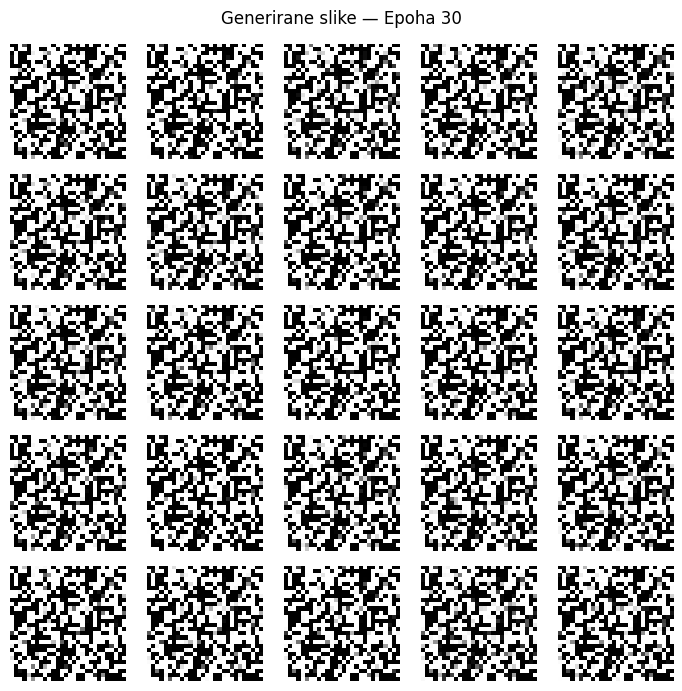

In [7]:
hist_d, hist_g = treniraj_gan(
    generator, discriminator, gan,
    X_train,
    latent_dim   = LATENT_DIM,
    n_epoha      = 30,
    batch_size   = 128,
    prikaz_svakih = 10
)

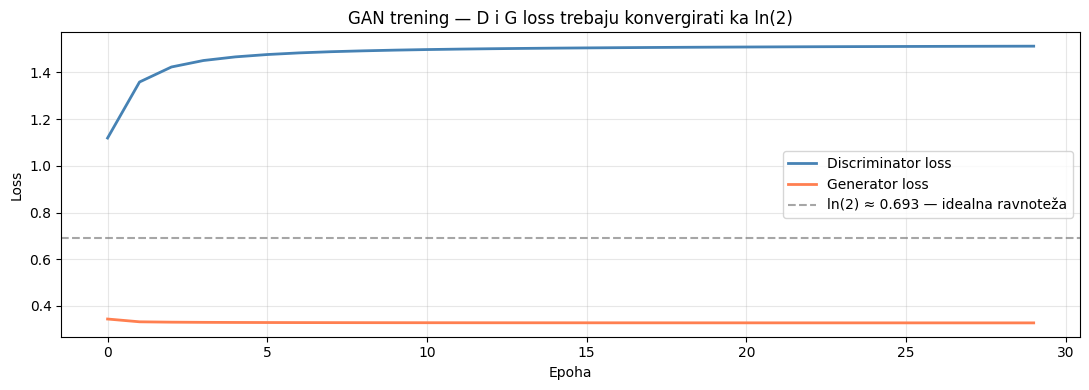

GAN interpretacija krive učenja — DRUGAČIJA od klasifikacije:
  D loss ≈ 0.693 (ln 2) → Discriminator ne može razlikovati stvarno od lažnog = IDEALNO
  G loss visok → Generator još ne vara D dovoljno dobro
  G loss nizak, D loss visok → Generator je pobijedio, ali možda mode collapse
  Oba rastu → nestabilan trening — treba smanjiti learning rate


In [8]:
# Kriva učenja — GAN specifičnost
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(hist_d, label='Discriminator loss', color='steelblue', linewidth=2)
ax.plot(hist_g, label='Generator loss',     color='coral',     linewidth=2)
ax.axhline(y=0.693, color='gray', linestyle='--', alpha=0.7,
           label='ln(2) ≈ 0.693 — idealna ravnoteža')
ax.set_title('GAN trening — D i G loss trebaju konvergirati ka ln(2)')
ax.set_xlabel('Epoha')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("GAN interpretacija krive učenja — DRUGAČIJA od klasifikacije:")
print("  D loss ≈ 0.693 (ln 2) → Discriminator ne može razlikovati stvarno od lažnog = IDEALNO")
print("  G loss visok → Generator još ne vara D dovoljno dobro")
print("  G loss nizak, D loss visok → Generator je pobijedio, ali možda mode collapse")
print("  Oba rastu → nestabilan trening — treba smanjiti learning rate")

Generirane slike NAKON treninga:


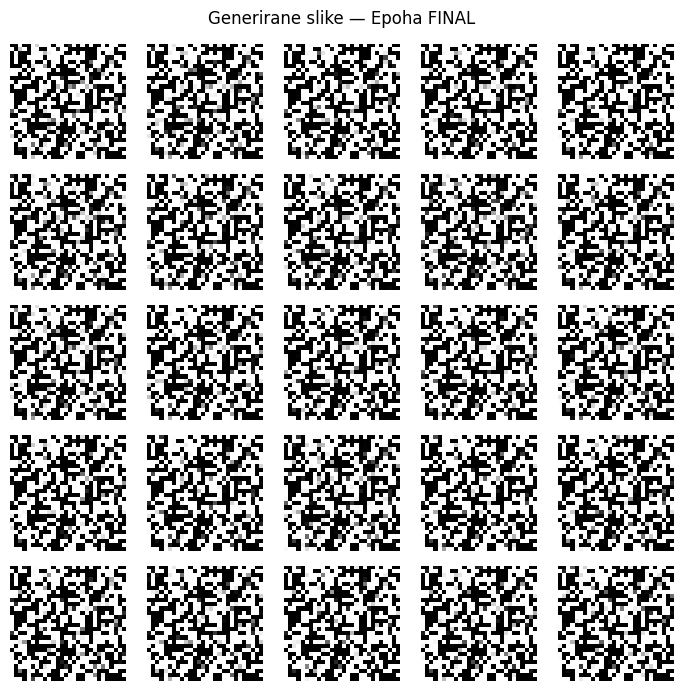


Usporedba: šum na početku vs. naučene slike na kraju
Generator je naučio mapirati Gaussov šum na distribuciju MNIST slika.


In [9]:
# Finalne generirane slike
print("Generirane slike NAKON treninga:")
prikazi_slike(generator, LATENT_DIM, epoha='FINAL', n=25)

print("\nUsporedba: šum na početku vs. naučene slike na kraju")
print("Generator je naučio mapirati Gaussov šum na distribuciju MNIST slika.")

### 3.5 Latentni prostor — interpolacija između cifara

Jedna od najljepših osobina GAN-a: možemo **interpolirati** između dvije tačke u latentnom prostoru i dobiti glatki prijelaz između slika.

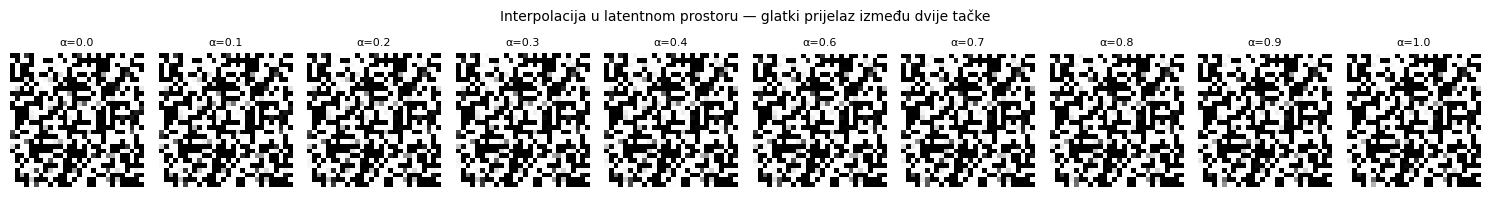

Glatki prijelaz = Generator je naučio kontinuiranu, smislenu reprezentaciju.
Mode collapse bi izgledao kao iste slike bez obzira na z.


In [10]:
# Interpolacija u latentnom prostoru
z1 = np.random.normal(0, 1, (1, LATENT_DIM))  # tačka A
z2 = np.random.normal(0, 1, (1, LATENT_DIM))  # tačka B

n_koraka = 10
alphe    = np.linspace(0, 1, n_koraka)

fig, axes = plt.subplots(1, n_koraka, figsize=(15, 2))
for i, alpha in enumerate(alphe):
    # Linearna interpolacija: alpha=0 → z1, alpha=1 → z2
    z_interp  = (1 - alpha) * z1 + alpha * z2
    generirano = generator.predict(z_interp, verbose=0)
    slika      = (generirano[0, :, :, 0] + 1) / 2.0
    axes[i].imshow(slika, cmap='gray')
    axes[i].set_title(f'α={alpha:.1f}', fontsize=8)
    axes[i].axis('off')

plt.suptitle('Interpolacija u latentnom prostoru — glatki prijelaz između dvije tačke', fontsize=10)
plt.tight_layout()
plt.show()

print("Glatki prijelaz = Generator je naučio kontinuiranu, smislenu reprezentaciju.")
print("Mode collapse bi izgledao kao iste slike bez obzira na z.")

---
## 4. Dio B — cGAN (Conditional GAN)

**Problem s Vanilla GAN-om:** Ne kontrolišemo što se generira. Dobijamo nasumičnu cifru.

**cGAN rješenje:** I Generator i Discriminator dobijaju dodatnu informaciju — **labelu klase**. Generator uči generisati sliku određene klase, Discriminator provjerava je li slika stvarna I odgovara li klasi.

```
Šum + Labela → [Generator] → Lažna slika te klase
Slika + Labela → [Discriminator] → Stvarna/Lažna I odgovara li klasi?
```

### 4.1 cGAN Generator

In [11]:
def napravi_cgan_generator(latent_dim, n_klasa):
    # Input 1: šum
    z_input     = keras.Input(shape=(latent_dim,), name='sum')
    # Input 2: labela klase (integer 0-9)
    label_input = keras.Input(shape=(1,), name='labela', dtype='int32')

    # Embedding: pretvori labelu u vektor dimenzije latent_dim
    # Embedding(n_klasa, latent_dim): svaka klasa dobija vlastiti naučeni vektor
    label_embed = layers.Embedding(n_klasa, latent_dim)(label_input)
    label_embed = layers.Flatten()(label_embed)  # (batch, latent_dim)

    # Spojimo šum i labelu — concatenation
    # Sada Generator zna I šum I željenu klasu
    x = layers.Multiply()([z_input, label_embed])  # element-wise multiply
    # Alternativa: layers.Concatenate()([z_input, label_embed])

    # Ista arhitektura kao Vanilla Generator
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Dense(28 * 28 * 1, activation='tanh')(x)
    output = layers.Reshape((28, 28, 1))(x)

    return keras.Model([z_input, label_input], output, name='cGAN_Generator')


cgen = napravi_cgan_generator(LATENT_DIM, N_KLASA)
cgen.summary()

print("\ncGAN Generator prima 2 inputa:")
print("  1. Šum: nasumičan vektor → raznolikost unutar klase")
print("  2. Labela: integer 0-9 → kontrola koja klasa se generira")

Model: "cGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ labela (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 100)    │      1,000 │ labela[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum (InputLayer)    │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 100)       │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 100)       │          0 │ sum[0][0],        │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     25,856 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 256)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 512)       │    131,584 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 512)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1024)      │    525,312 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 784)       │    803,600 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,494,520 (5.70 MB)

 Trainable params: 1,490,936 (5.69 MB)

 Non-trainable params: 3,584 (14.00 KB)


cGAN Generator prima 2 inputa:
  1. Šum: nasumičan vektor → raznolikost unutar klase
  2. Labela: integer 0-9 → kontrola koja klasa se generira


### 4.2 cGAN Discriminator

In [12]:
def napravi_cgan_discriminator(n_klasa):
    # Input 1: slika
    img_input   = keras.Input(shape=IMG_SHAPE, name='slika')
    # Input 2: labela
    label_input = keras.Input(shape=(1,), name='labela', dtype='int32')

    # Embedding labele na veličinu slike (784 = 28*28)
    label_embed = layers.Embedding(n_klasa, 28 * 28)(label_input)
    label_embed = layers.Reshape((28, 28, 1))(label_embed)
    # Sada labela ima isti shape kao slika!

    # Spojimo sliku i labelu kao kanale
    # Slika: (28, 28, 1) + Labela: (28, 28, 1) → (28, 28, 2)
    x = layers.Concatenate()([img_input, label_embed])

    x = layers.Flatten()(x)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model([img_input, label_input], output, name='cGAN_Discriminator')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


cdis = napravi_cgan_discriminator(N_KLASA)
print("cGAN Discriminator prima 2 inputa:")
print("  1. Slika: 28×28 — da li izgleda realno?")
print("  2. Labela: odgovara li slika toj klasi?")

cGAN Discriminator prima 2 inputa:
  1. Slika: 28×28 — da li izgleda realno?
  2. Labela: odgovara li slika toj klasi?


### 4.3 cGAN kompletan model i trening

In [13]:
# cGAN = cGenerator + zamrznuti cDiscriminator
z_input     = keras.Input(shape=(LATENT_DIM,))
label_input = keras.Input(shape=(1,), dtype='int32')

fake_img = cgen([z_input, label_input])

cdis.trainable = False
validity = cdis([fake_img, label_input])

cgan = keras.Model([z_input, label_input], validity, name='cGAN')
cgan.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss='binary_crossentropy'
)

print("cGAN model spreman.")

cGAN model spreman.


In [14]:
def prikazi_cgan_slike(generator, latent_dim, n_klasa, epoha):
    """Prikazuje po jednu generiranu sliku za svaku klasu."""
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for klasa in range(n_klasa):
        z = np.random.normal(0, 1, (1, latent_dim))
        labela = np.array([[klasa]])
        generirano = generator.predict([z, labela], verbose=0)
        slika = (generirano[0, :, :, 0] + 1) / 2.0
        ax = axes[klasa // 5, klasa % 5]
        ax.imshow(slika, cmap='gray')
        ax.set_title(f'Klasa: {klasa}', fontsize=10)
        ax.axis('off')
    plt.suptitle(f'cGAN generirane slike po klasi — Epoha {epoha}', fontsize=11)
    plt.tight_layout()
    plt.show()


def treniraj_cgan(cgen, cdis, cgan, X_train, y_train,
                  latent_dim, n_klasa,
                  n_epoha=30, batch_size=128,
                  prikaz_svakih=10):

    n_batch     = X_train.shape[0] // batch_size
    hist_d, hist_g = [], []

    prave_labele = np.ones((batch_size, 1)) * 0.9
    lazne_labele = np.zeros((batch_size, 1))

    print(f"cGAN Trening: {n_epoha} epoha")
    print("-" * 55)

    for epoha in range(1, n_epoha + 1):
        d_lossi, g_lossi = [], []

        for _ in range(n_batch):
            # ── Discriminator ────────────────────────────────────
            # Stvarne slike s pravim labelama
            idx          = np.random.randint(0, X_train.shape[0], batch_size)
            prave_slike  = X_train[idx]
            prave_kl     = y_train[idx].reshape(-1, 1)

            cdis.trainable = True
            d_loss_p = cdis.train_on_batch([prave_slike, prave_kl], prave_labele)

            # Lažne slike s nasumičnim labelama
            z           = np.random.normal(0, 1, (batch_size, latent_dim))
            lazne_kl    = np.random.randint(0, n_klasa, (batch_size, 1))
            lazne_slike = cgen.predict([z, lazne_kl], verbose=0)

            d_loss_l = cdis.train_on_batch([lazne_slike, lazne_kl], lazne_labele)
            d_lossi.append(0.5 * (d_loss_p[0] + d_loss_l[0]))

            # ── Generator ────────────────────────────────────────
            z        = np.random.normal(0, 1, (batch_size, latent_dim))
            lazne_kl = np.random.randint(0, n_klasa, (batch_size, 1))

            cdis.trainable = False
            g_loss = cgan.train_on_batch([z, lazne_kl], prave_labele)
            g_lossi.append(g_loss)

        d_avg = np.mean(d_lossi)
        g_avg = np.mean(g_lossi)
        hist_d.append(d_avg)
        hist_g.append(g_avg)

        print(f"Epoha {epoha:3d}/{n_epoha}  |  D loss: {d_avg:.4f}  |  G loss: {g_avg:.4f}")

        if epoha % prikaz_svakih == 0 or epoha == 1:
            prikazi_cgan_slike(cgen, latent_dim, n_klasa, epoha)

    return hist_d, hist_g


print("cGAN spreman za trening.")

cGAN spreman za trening.


cGAN Trening: 30 epoha
-------------------------------------------------------
Epoha   1/30  |  D loss: 0.3066  |  G loss: 0.7868


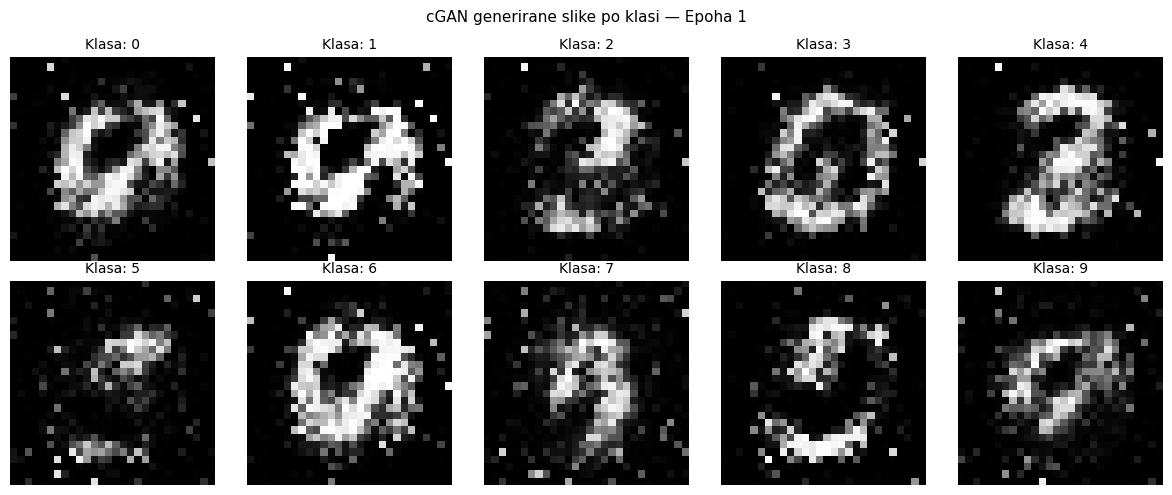

Epoha   2/30  |  D loss: 0.4050  |  G loss: 1.4136
Epoha   3/30  |  D loss: 0.4548  |  G loss: 1.5819
Epoha   4/30  |  D loss: 0.4838  |  G loss: 1.5763
Epoha   5/30  |  D loss: 0.5168  |  G loss: 1.4791
Epoha   6/30  |  D loss: 0.5411  |  G loss: 1.3917
Epoha   7/30  |  D loss: 0.5601  |  G loss: 1.3220
Epoha   8/30  |  D loss: 0.5755  |  G loss: 1.2655
Epoha   9/30  |  D loss: 0.5873  |  G loss: 1.2212
Epoha  10/30  |  D loss: 0.5973  |  G loss: 1.1853


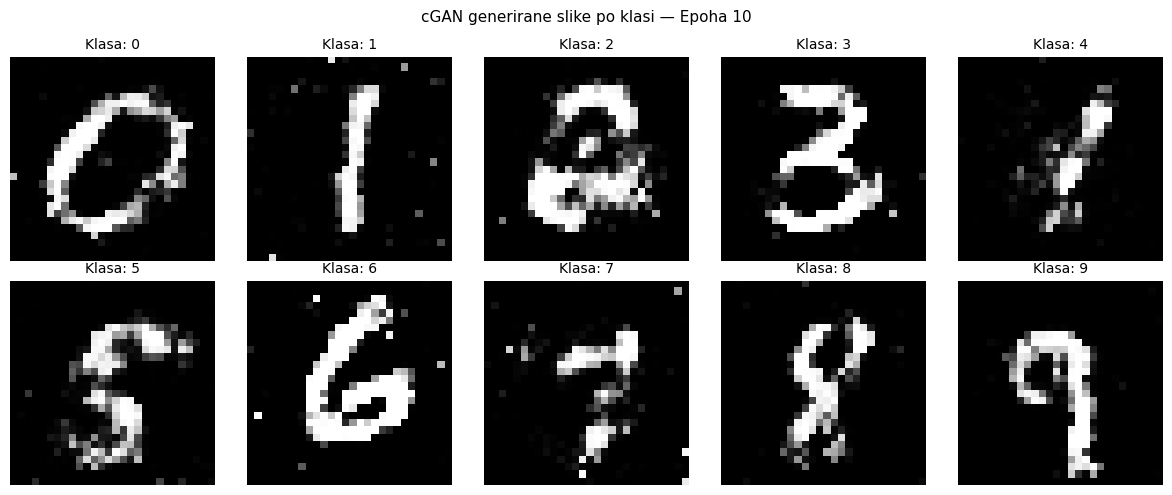

Epoha  11/30  |  D loss: 0.6059  |  G loss: 1.1547
Epoha  12/30  |  D loss: 0.6131  |  G loss: 1.1285
Epoha  13/30  |  D loss: 0.6191  |  G loss: 1.1057
Epoha  14/30  |  D loss: 0.6245  |  G loss: 1.0859
Epoha  15/30  |  D loss: 0.6291  |  G loss: 1.0684
Epoha  16/30  |  D loss: 0.6332  |  G loss: 1.0528
Epoha  17/30  |  D loss: 0.6367  |  G loss: 1.0388
Epoha  18/30  |  D loss: 0.6399  |  G loss: 1.0264
Epoha  19/30  |  D loss: 0.6426  |  G loss: 1.0151
Epoha  20/30  |  D loss: 0.6452  |  G loss: 1.0050


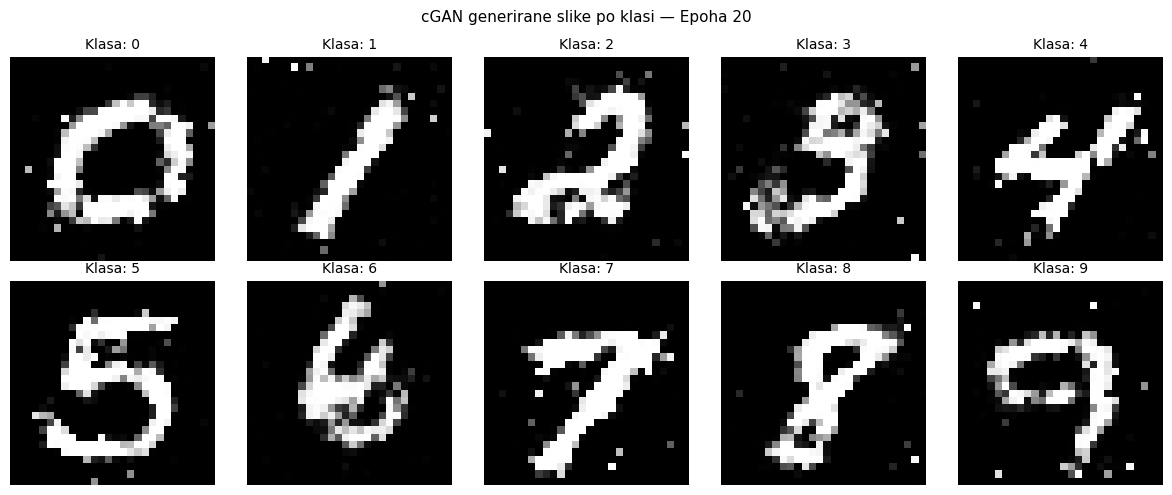

Epoha  21/30  |  D loss: 0.6474  |  G loss: 0.9958
Epoha  22/30  |  D loss: 0.6494  |  G loss: 0.9874
Epoha  23/30  |  D loss: 0.6512  |  G loss: 0.9797
Epoha  24/30  |  D loss: 0.6529  |  G loss: 0.9725
Epoha  25/30  |  D loss: 0.6544  |  G loss: 0.9659
Epoha  26/30  |  D loss: 0.6558  |  G loss: 0.9598
Epoha  27/30  |  D loss: 0.6570  |  G loss: 0.9541
Epoha  28/30  |  D loss: 0.6582  |  G loss: 0.9489
Epoha  29/30  |  D loss: 0.6592  |  G loss: 0.9440
Epoha  30/30  |  D loss: 0.6602  |  G loss: 0.9394


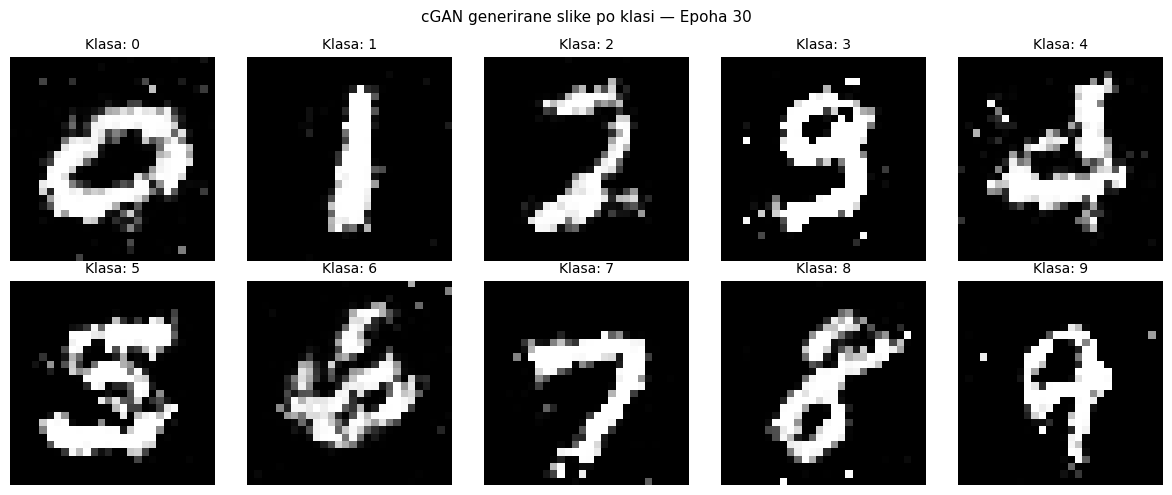

In [15]:
chist_d, chist_g = treniraj_cgan(
    cgen, cdis, cgan,
    X_train, y_train,
    latent_dim    = LATENT_DIM,
    n_klasa       = N_KLASA,
    n_epoha       = 30,
    batch_size    = 128,
    prikaz_svakih = 10
)

### 4.4 cGAN — kontrolirano generisanje

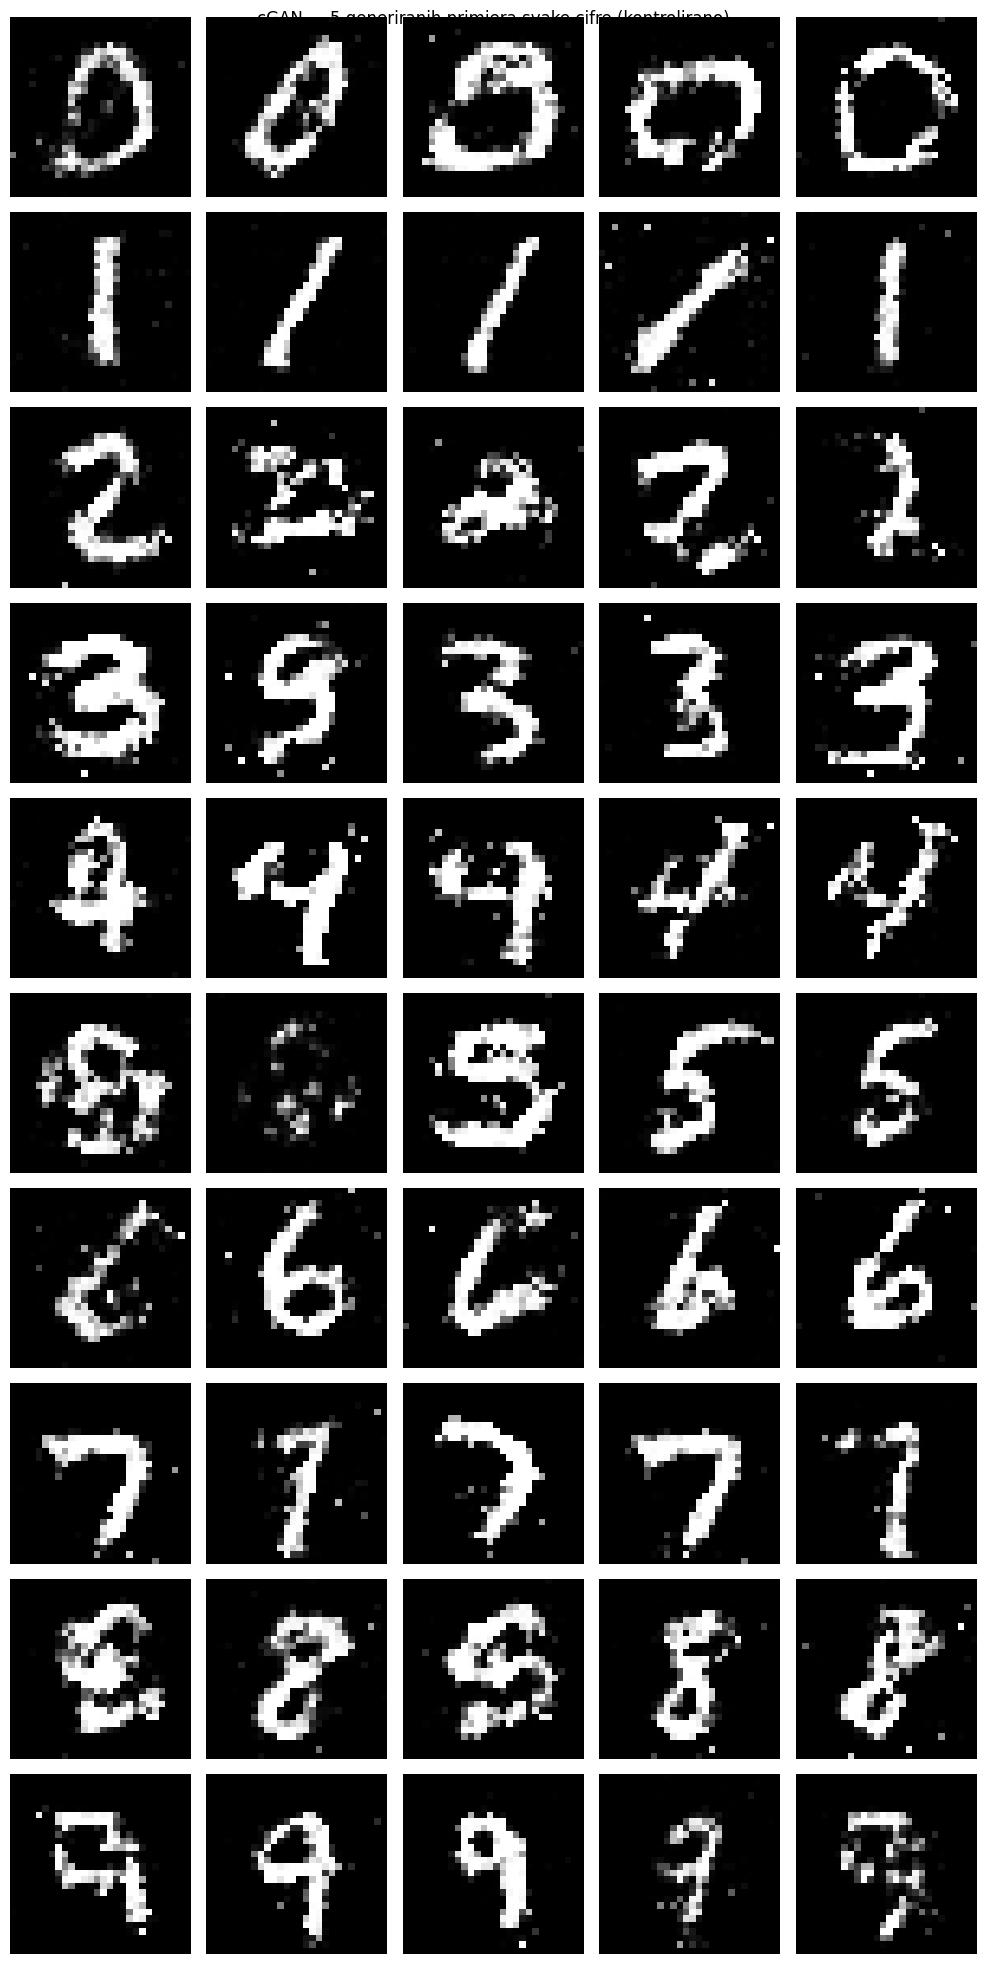

Svaki red = jedna klasa, svaka kolona = novi nasumični šum
cGAN kontroliše klasu, ali šum donosi raznolikost unutar klase


In [16]:
# Generišemo po 5 primjera svake cifre
n_po_klasi = 5
fig, axes  = plt.subplots(N_KLASA, n_po_klasi, figsize=(10, 20))

for klasa in range(N_KLASA):
    for j in range(n_po_klasi):
        z      = np.random.normal(0, 1, (1, LATENT_DIM))
        labela = np.array([[klasa]])
        slika  = cgen.predict([z, labela], verbose=0)
        slika  = (slika[0, :, :, 0] + 1) / 2.0
        axes[klasa, j].imshow(slika, cmap='gray')
        axes[klasa, j].axis('off')
        if j == 0:
            axes[klasa, j].set_ylabel(f'Cifra {klasa}', fontsize=11,
                                      rotation=0, labelpad=40, va='center')

plt.suptitle('cGAN — 5 generiranih primjera svake cifre (kontrolirano)', fontsize=12)
plt.tight_layout()
plt.show()

print("Svaki red = jedna klasa, svaka kolona = novi nasumični šum")
print("cGAN kontroliše klasu, ali šum donosi raznolikost unutar klase")

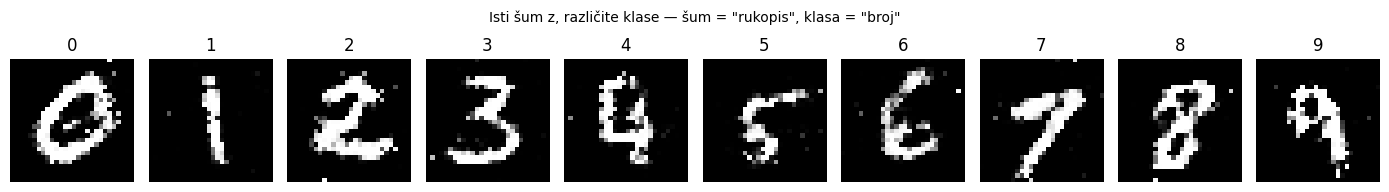

In [17]:
# Isti šum, različite klase — šum određuje 'stil', klasa određuje 'sadržaj'
isti_z = np.random.normal(0, 1, (1, LATENT_DIM))

fig, axes = plt.subplots(1, N_KLASA, figsize=(14, 2))
for klasa in range(N_KLASA):
    labela = np.array([[klasa]])
    slika  = cgen.predict([isti_z, labela], verbose=0)
    slika  = (slika[0, :, :, 0] + 1) / 2.0
    axes[klasa].imshow(slika, cmap='gray')
    axes[klasa].set_title(str(klasa), fontsize=12)
    axes[klasa].axis('off')

plt.suptitle('Isti šum z, različite klase — šum = "rukopis", klasa = "broj"', fontsize=10)
plt.tight_layout()
plt.show()

---
## 5. GAN problemi koje trebate znati

GAN trening je nestabilan u praksi. Postoje karakteristični problemi:

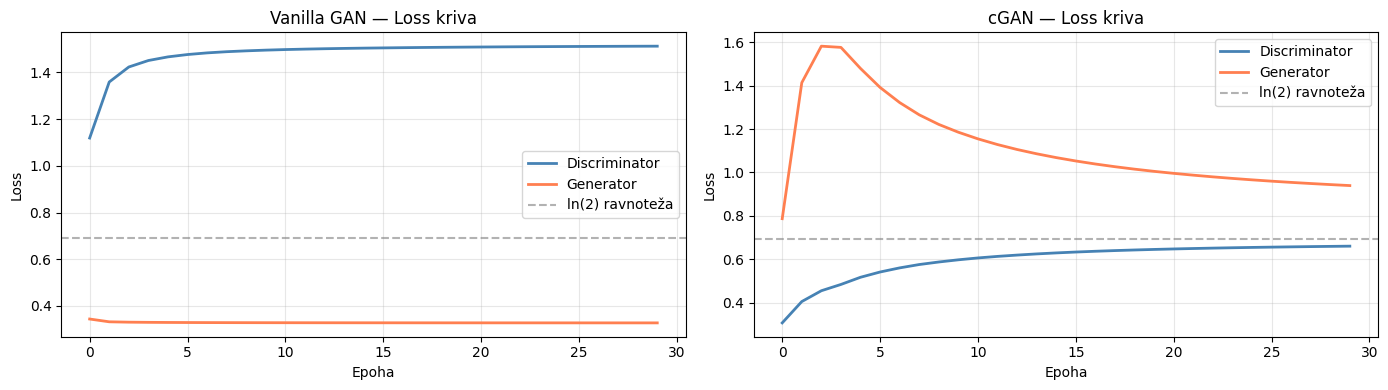

Uobičajeni GAN problemi:

  1. MODE COLLAPSE
     Generator počne generirati samo jednu ili par sličnih slika
     Razlog: Generator nađe 'rupu' u Discriminatoru i eksploatiše je
     Rješenje: Minibatch discrimination, spektralna normalizacija

  2. NESTABILAN TRENING
     Loss oscilira, G i D se ne uravnotežuju
     Rješenje: manji LR, label smoothing (0.9 umjesto 1.0), gradient penalty

  3. VANISHING GRADIENTS
     Discriminator postane predobar → Generator dobiva gradijent ≈ 0
     Rješenje: Wasserstein GAN (WGAN) s drugačijim loss-om


In [18]:
# Vizualizacija GAN vs cGAN loss kriva
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (hd, hg, naziv) in zip(axes, [
    (hist_d,  hist_g,  'Vanilla GAN'),
    (chist_d, chist_g, 'cGAN'),
]):
    ax.plot(hd, label='Discriminator', color='steelblue', linewidth=2)
    ax.plot(hg, label='Generator',     color='coral',     linewidth=2)
    ax.axhline(0.693, color='gray', linestyle='--', alpha=0.6, label='ln(2) ravnoteža')
    ax.set_title(f'{naziv} — Loss kriva')
    ax.set_xlabel('Epoha')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Uobičajeni GAN problemi:")
print()
print("  1. MODE COLLAPSE")
print("     Generator počne generirati samo jednu ili par sličnih slika")
print("     Razlog: Generator nađe 'rupu' u Discriminatoru i eksploatiše je")
print("     Rješenje: Minibatch discrimination, spektralna normalizacija")
print()
print("  2. NESTABILAN TRENING")
print("     Loss oscilira, G i D se ne uravnotežuju")
print("     Rješenje: manji LR, label smoothing (0.9 umjesto 1.0), gradient penalty")
print()
print("  3. VANISHING GRADIENTS")
print("     Discriminator postane predobar → Generator dobiva gradijent ≈ 0")
print("     Rješenje: Wasserstein GAN (WGAN) s drugačijim loss-om")

---
## 6. Šta smo naučili danas

| Koncept | Šta znači |
|---|---|
| **Generator** | Mreža koja kreira lažne podatke iz šuma |
| **Discriminator** | Mreža koja razlikuje stvarno od lažnog |
| **Latentni prostor** | N-dimenzionalni prostor šuma — svaka tačka → jedna slika |
| **Adversarial trening** | G i D se takmiče, oba se poboljšavaju |
| **tanh output** | Generator koristi tanh, podaci u [-1,1] |
| **Label smoothing** | 0.9 umjesto 1.0 za stabilniji trening |
| **cGAN** | Conditional GAN — kontrolišemo klasu ulaznom labelom |
| **Embedding** | Pretvara integer labelu u naučeni vektor |
| **ln(2) ≈ 0.693** | Idealni D loss — ne može razlikovati stvarno od lažnog |
| **Mode collapse** | G generira samo jedan/par uzoraka — najčešći GAN problem |
| **Interpolacija** | Glatki prijelaz između tačaka latentnog prostora |

---
## ZADATAK 4 BODA


### Šta trebate uraditi:

1. **Pokrenite cGAN** iz notebooka do kraja i sačuvajte sve outpute (slike po epohama, loss kriva, kontrolirano generisanje)

2. **Eksperimentirajte s jednom od sljedeće dvije varijante** (vaš izbor):
   - **Varijanta A — Arhitektura:** Promijenite cGAN Generator — dodajte još jedan Dense layer (1024→2048) ili promijenite `LeakyReLU` alpha s 0.2 na 0.3. Pokrenite 20 epoha i usporedite vizuelno s originalnim.
   - **Varijanta B — Fashion-MNIST:** Zamijenite MNIST s Fashion-MNIST (`from tensorflow.keras.datasets import fashion_mnist`). Istrenirajte cGAN i generirajte odjevne predmete po kategorijama.

3. **Napišite komentar** (markdown ćelija na kraju):
   - Koju varijantu ste odabrali i zašto?
   - Primijetili ste li mode collapse? Kako ste prepoznali?
   - Šta se desi s generiranim slikama ako je D loss = 0? Zašto je to loše za Generator?


### Bodovanje:
- **1 bod** — cGAN pokrenut do kraja, slike po epohama i loss kriva sačuvani
- **1 bod** — Jedna varijanta implementirana i vizuelno uspoređena s originalnim
- **1 bod** — Komentar koji odgovara na sva tri pitanja
- **1 bod** — Implementirajte interpolaciju u latentnom prostoru (kao u ćeliji 3.5) ali za cGAN — interpolirajte između dvije slike ISTE klase. Šta vidite?